### Configuration, inputs & outputs

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import mannwhitneyu

from pipeline_utils import make_case3_paths

paths = make_case3_paths()

## Raw omics matrices (for gene-coverage check)
mcgill_mut_raw = paths["datasets"] / "mcgill_breast" / "mutation_matrix.csv"
mcgill_cnv_raw = paths["datasets"] / "mcgill_breast" / "CNV_matrix.csv"
uhn_mut_raw = paths["datasets"] / "uhn_breast" / "mutation_matrix.csv"
uhn_cnv_raw = paths["datasets"] / "uhn_breast" / "CNV_matrix.csv"
gene_file = paths["raw"] / "nest_vnn" / "gene2ind.txt"

## Final NeST-VNN input matrices (cell x gene, binary; row order matches cell2ind.txt)
mcgill_dir = paths["proc"] / "McGill_nest_input"
uhn_complete_dir = paths["proc"] / "UHN_nest_input" / "complete_cohort"
uhn_strict_dir = paths["proc"] / "UHN_nest_input" / "strict_cohort"

## Output
figures_dir = paths["results"]
figures_dir.mkdir(parents=True, exist_ok=True)

### Gene coverage: how many of the 718 NeST-VNN genes have data in each cohort

In [2]:
gene_list = pd.read_csv(gene_file, sep="\t", header=None)[1].tolist()
print("NeST-VNN target genes:", len(gene_list))


def n_covered(matrix_path, gene_list):
    genes_present = set(pd.read_csv(matrix_path, index_col=0).index)
    return sum(g in genes_present for g in gene_list)


coverage = pd.DataFrame([
    {"cohort": "UHN Carboplatin", "data_type": "Mutation", "genes_covered": n_covered(uhn_mut_raw, gene_list)},
    {"cohort": "UHN Carboplatin", "data_type": "CNV", "genes_covered": n_covered(uhn_cnv_raw, gene_list)},
    {"cohort": "McGill Cisplatin", "data_type": "Mutation", "genes_covered": n_covered(mcgill_mut_raw, gene_list)},
    {"cohort": "McGill Cisplatin", "data_type": "CNV", "genes_covered": n_covered(mcgill_cnv_raw, gene_list)},
])
coverage["total_genes"] = len(gene_list)
coverage["pct_covered"] = (coverage["genes_covered"] / len(gene_list) * 100).round(1)
print(coverage.to_string(index=False))

NeST-VNN target genes: 718
          cohort data_type  genes_covered  total_genes  pct_covered
 UHN Carboplatin  Mutation            670          718         93.3
 UHN Carboplatin       CNV            711          718         99.0
McGill Cisplatin  Mutation            235          718         32.7
McGill Cisplatin       CNV            717          718         99.9


In [ ]:
coverage_out = paths["results"] / "case3_gene_coverage.csv"
coverage.to_csv(coverage_out, index=False)
print(f"Saved: {coverage_out}")

### Gene coverage plot

Saved: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/3_carboplatin/case3_gene_coverage.png


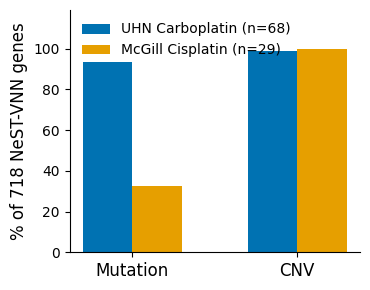

In [3]:
COHORT_COLORS = {"UHN Carboplatin": "#0072B2", "McGill Cisplatin": "#E69F00"}
COHORT_N = {"UHN Carboplatin": 68, "McGill Cisplatin": 29}

fig, ax = plt.subplots(figsize=(3.8, 3))

data_types = ["Mutation", "CNV"]
x = np.arange(len(data_types)) * 0.6
width = 0.18

for offset, cohort in zip([-width / 2, width / 2], COHORT_COLORS):
    sub = coverage[coverage["cohort"] == cohort].set_index("data_type").loc[data_types]
    bars = ax.bar(x + offset, sub["pct_covered"], width, label=f"{cohort} (n={COHORT_N[cohort]})", color=COHORT_COLORS[cohort])
    # for bar, pct, n in zip(bars, sub["pct_covered"], sub["genes_covered"]):
    #     ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5, f"{n}/718",
    #              ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(data_types, fontsize=12)
ax.set_ylabel("% of 718 NeST-VNN genes", fontsize=12)
ax.set_ylim(0, 119)
# ax.set_title("Gene coverage completeness by cohort")
ax.legend(frameon=False, loc="upper left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()

out_path = figures_dir / "case3_gene_coverage.png"
plt.savefig(out_path, dpi=300)
print("Saved:", out_path)
plt.show()

### Does the Mutation gene-coverage gap (panel b) confound the Mutation significance test (panel c)?

Panel b shows McGill has real mutation data for only 235/718 NeST-VNN genes vs. UHN's 670/718. Since
uncovered genes are filled with 0 ("no mutation") in the final matrices, McGill's per-model mutation
counts could be artificially low simply because ~483 genes were never observed, not because McGill
models are truly less mutated. To check: restrict the comparison to only the genes **both cohorts
actually have coverage for**, and re-run the same Mann-Whitney test.

In [4]:
mcgill_mut_genes = set(pd.read_csv(mcgill_mut_raw, index_col=0).index)
uhn_mut_genes = set(pd.read_csv(uhn_mut_raw, index_col=0).index)
common_mut_genes = [g for g in gene_list if g in mcgill_mut_genes and g in uhn_mut_genes]
print(f"Genes with mutation data in BOTH cohorts: {len(common_mut_genes)} / {len(gene_list)}")


def load_mutation_df(nest_dir):
    df = pd.read_csv(nest_dir / "cell2mutation.txt", header=None)
    df.columns = gene_list
    return df


mcgill_mut_df = load_mutation_df(mcgill_dir)
uhn_mut_df = load_mutation_df(uhn_complete_dir)

# Original comparison: all 718 genes (uncovered genes filled with 0)
mcgill_all = mcgill_mut_df.sum(axis=1).to_numpy()
uhn_all = uhn_mut_df.sum(axis=1).to_numpy()
stat_all, p_all = mannwhitneyu(uhn_all, mcgill_all, alternative="two-sided")
print(f"\nMutation, all 718 genes:        U={stat_all:.1f}, p={p_all:.2e} "
      f"(McGill median={np.median(mcgill_all):.1f}, UHN median={np.median(uhn_all):.1f})")

# Restricted comparison: only genes both cohorts actually have coverage for
mcgill_common = mcgill_mut_df[common_mut_genes].sum(axis=1).to_numpy()
uhn_common = uhn_mut_df[common_mut_genes].sum(axis=1).to_numpy()
stat_c, p_c = mannwhitneyu(uhn_common, mcgill_common, alternative="two-sided")
print(f"Mutation, {len(common_mut_genes)} common-covered genes: U={stat_c:.1f}, p={p_c:.2e} "
      f"(McGill median={np.median(mcgill_common):.1f}, UHN median={np.median(uhn_common):.1f})")

print("\n-> The difference weakens substantially once uncovered genes are excluded, but remains "
      "statistically significant -- the coverage gap inflates the effect, but doesn't fully explain it.")

Genes with mutation data in BOTH cohorts: 232 / 718

Mutation, all 718 genes:        U=1824.5, p=3.81e-11 (McGill median=7.0, UHN median=17.5)
Mutation, 232 common-covered genes: U=1348.0, p=4.23e-03 (McGill median=7.0, UHN median=9.0)

-> The difference weakens substantially once uncovered genes are excluded, but remains statistically significant -- the coverage gap inflates the effect, but doesn't fully explain it.


#### Supplemental panel: Mutation burden, all 718 genes vs. common-covered genes only

  All 718
genes: U=1824.5, p=3.81e-11 (****)
  Common 232
genes: U=1348.0, p=4.23e-03 (**)
Saved: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/3_carboplatin/case3_mutation_coverage_confound_check.png


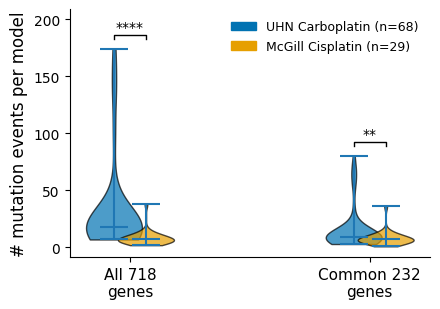

In [5]:
GROUPS = [
    ("All 718\ngenes", mcgill_all, uhn_all),
    (f"Common {len(common_mut_genes)}\ngenes", mcgill_common, uhn_common),
]

fig, ax = plt.subplots(figsize=(4.5, 3.2))

positions, plot_data, colors = [], [], []
xticks, xticklabels = [], []
for i, (label, mcgill_vals, uhn_vals) in enumerate(GROUPS):
    plot_data += [uhn_vals, mcgill_vals]
    positions += [i * 3 + 0.8, i * 3 + 1.2]
    colors += [COHORT_COLORS["UHN Carboplatin"], COHORT_COLORS["McGill Cisplatin"]]
    xticks.append(i * 3 + 1)
    xticklabels.append(label)

parts = ax.violinplot(plot_data, positions=positions, widths=0.7, showmedians=True)
for pc, color in zip(parts["bodies"], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
    pc.set_edgecolor("black")

ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels, fontsize=11)
ax.set_ylabel("# mutation events per model", fontsize=12)
ax.legend(
    handles=[
        Patch(color=COHORT_COLORS["UHN Carboplatin"], label=f"UHN Carboplatin (n={len(uhn_all)})"),
        Patch(color=COHORT_COLORS["McGill Cisplatin"], label=f"McGill Cisplatin (n={len(mcgill_all)})"),
    ],
    frameon=False, loc="upper right", fontsize=9,
)

y_max = max(d.max() for d in plot_data)
cap = y_max * 0.02
gap = y_max * 0.05
for i, (label, mcgill_vals, uhn_vals) in enumerate(GROUPS):
    stat, p = mannwhitneyu(uhn_vals, mcgill_vals, alternative="two-sided")
    if p < 0.0001:
        sig = "****"
    elif p < 0.001:
        sig = "***"
    elif p < 0.01:
        sig = "**"
    elif p < 0.05:
        sig = "*"
    else:
        sig = "ns"
    print(f"  {label.strip()}: U={stat:.1f}, p={p:.2e} ({sig})")

    x1, x2 = i * 3 + 0.8, i * 3 + 1.2
    group_max = max(uhn_vals.max(), mcgill_vals.max())
    y = group_max + gap
    ax.plot([x1, x1, x2, x2], [y, y + cap, y + cap, y], color="black", linewidth=1)
    ax.text((x1 + x2) / 2, y + cap * 1.2, sig, ha="center", va="bottom", fontsize=10)

ax.set_ylim(top=y_max * 1.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()

out_path = figures_dir / "case3_mutation_coverage_confound_check.png"
plt.savefig(out_path, dpi=300)
print("Saved:", out_path)
plt.show()

### Per-model event burden: Mutation / CNA / CND

In [6]:
def load_event_counts(nest_dir):
    """Per-model event counts from the final NeST-VNN cell x gene binary matrices."""
    mut = pd.read_csv(nest_dir / "cell2mutation.txt", header=None)
    cna = pd.read_csv(nest_dir / "cell2amplification.txt", header=None)
    cnd = pd.read_csv(nest_dir / "cell2cndeletion.txt", header=None)
    return {
        "Mutation": mut.sum(axis=1).to_numpy(),
        "CNA": cna.sum(axis=1).to_numpy(),
        "CND": cnd.sum(axis=1).to_numpy(),
    }


# UHN "complete" cohort used here (largest available N); "strict" cohort is
# available at uhn_strict_dir if the n_replicates->=2 subset is preferred instead.
mcgill_events = load_event_counts(mcgill_dir)
uhn_events = load_event_counts(uhn_complete_dir)

print(f"McGill Cisplatin: n={len(mcgill_events['Mutation'])}")
print(f"UHN Carboplatin (complete): n={len(uhn_events['Mutation'])}")

McGill Cisplatin: n=29
UHN Carboplatin (complete): n=68


### Density comparison + Mann-Whitney U test

Mann-Whitney U test (two-sided): UHN Carboplatin vs McGill Cisplatin
  Mutation: U=1824.5, p=3.81e-11 (****)
  CNA: U=858.5, p=3.17e-01 (ns)
  CND: U=1175.5, p=1.36e-01 (ns)

Saved: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/3_carboplatin/case3_feature_density_comparison.png


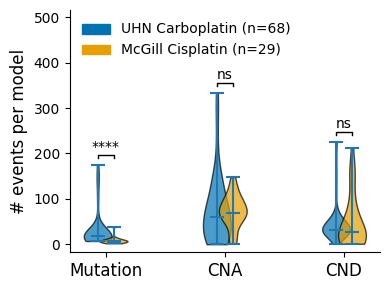

In [7]:
FEATURE_TYPES = ["Mutation", "CNA", "CND"]

fig, ax = plt.subplots(figsize=(4, 3))

positions, plot_data, colors = [], [], []
xticks, xticklabels = [], []
for i, ft in enumerate(FEATURE_TYPES):
    plot_data += [uhn_events[ft], mcgill_events[ft]]
    positions += [i * 3 + 0.8, i * 3 + 1.2]
    colors += [COHORT_COLORS["UHN Carboplatin"], COHORT_COLORS["McGill Cisplatin"]]
    xticks.append(i * 3 + 1)
    xticklabels.append(ft)

parts = ax.violinplot(plot_data, positions=positions, widths=0.7, showmedians=True)
for pc, color in zip(parts["bodies"], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
    pc.set_edgecolor("black")

ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels, fontsize = 12)
ax.set_ylabel("# events per model", fontsize= 12)
#ax.set_title("Density comparison of 718 NeST-VNN features")
ax.legend(
    handles=[
        Patch(color=COHORT_COLORS["UHN Carboplatin"], label=f"UHN Carboplatin (n={len(uhn_events['Mutation'])})"),
        Patch(color=COHORT_COLORS["McGill Cisplatin"], label=f"McGill Cisplatin (n={len(mcgill_events['Mutation'])})"),
    ],
    frameon=False, loc="upper left", fontsize = 10
)

print("Mann-Whitney U test (two-sided): UHN Carboplatin vs McGill Cisplatin")
y_max = max(d.max() for d in plot_data)
cap = y_max * 0.02
gap = y_max * 0.05
for i, ft in enumerate(FEATURE_TYPES):
    stat, p = mannwhitneyu(uhn_events[ft], mcgill_events[ft], alternative="two-sided")
    if p < 0.0001:
        sig = "****"
    elif p < 0.001:
        sig = "***"
    elif p < 0.01:
        sig = "**"
    elif p < 0.05:
        sig = "*"
    else:
        sig = "ns"
    print(f"  {ft}: U={stat:.1f}, p={p:.2e} ({sig})")

    x1, x2 = i * 3 + 0.8, i * 3 + 1.2
    group_max = max(uhn_events[ft].max(), mcgill_events[ft].max())
    y = group_max + gap
    ax.plot([x1, x1, x2, x2], [y, y + cap, y + cap, y], color="black", linewidth=1)
    ax.text((x1 + x2) / 2, y + cap * 1.2, sig, ha="center", va="bottom", fontsize=10)

ax.set_ylim(top=y_max * 1.55)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()

out_path = figures_dir / "case3_feature_density_comparison.png"
plt.savefig(out_path, dpi=300)
print("\nSaved:", out_path)
plt.show()

In [ ]:
# Same Mann-Whitney U test as the significance brackets drawn above, recomputed here
# to save the underlying figure statistics as a table.
mw_rows = []
for ft in FEATURE_TYPES:
    stat, p = mannwhitneyu(uhn_events[ft], mcgill_events[ft], alternative="two-sided")
    mw_rows.append({
        "feature_type": ft, "U_stat": stat, "p_value": p,
        "n_UHN": len(uhn_events[ft]), "n_McGill": len(mcgill_events[ft]),
    })
event_burden_mw = pd.DataFrame(mw_rows)
event_burden_mw_out = paths["results"] / "case3_event_burden_mannwhitney.csv"
event_burden_mw.to_csv(event_burden_mw_out, index=False)
print(f"Saved: {event_burden_mw_out}")
event_burden_mw

### Replicate condition: McGill (single-arm only) vs UHN complete vs UHN strict (>=2 arms)

In [8]:
mcgill_models = pd.read_csv(paths["proc"] / "McGill_cisplatin_models.tsv", sep="\t")
uhn_models = pd.read_csv(paths["proc"] / "UHN_carboplatin_models.tsv", sep="\t")

mcgill_reps = mcgill_models["n_replicates"]
uhn_reps = uhn_models["n_replicates"]
uhn_strict_reps = uhn_reps[uhn_reps >= 2]

print(f"McGill Cisplatin: n={len(mcgill_reps)}, n_replicates range {mcgill_reps.min()}-{mcgill_reps.max()}")
print(f"UHN Carboplatin (complete): n={len(uhn_reps)}, n_replicates range {uhn_reps.min()}-{uhn_reps.max()}")
print(f"UHN Carboplatin (strict, >=2): n={len(uhn_strict_reps)}")

McGill Cisplatin: n=29, n_replicates range 1-1
UHN Carboplatin (complete): n=68, n_replicates range 1-7
UHN Carboplatin (strict, >=2): n=36


#### Grouped frequency histogram (McGill vs UHN complete), with UHN-strict cutoff marked

Saved: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/3_carboplatin/case3_replicate_histogram.png


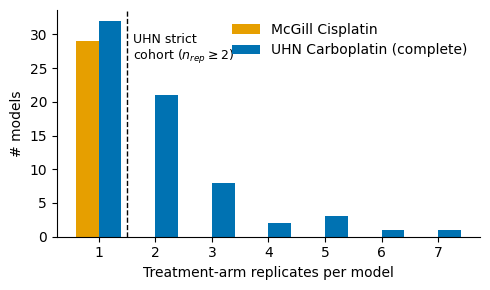

In [9]:
max_rep = int(max(mcgill_reps.max(), uhn_reps.max()))
bins = np.arange(1, max_rep + 1)

mcgill_counts = mcgill_reps.value_counts().reindex(bins, fill_value=0)
uhn_counts = uhn_reps.value_counts().reindex(bins, fill_value=0)

fig, ax = plt.subplots(figsize=(5, 3))
width = 0.4
ax.bar(bins - width / 2, mcgill_counts, width, label="McGill Cisplatin", color=COHORT_COLORS["McGill Cisplatin"])
ax.bar(bins + width / 2, uhn_counts, width, label="UHN Carboplatin (complete)", color=COHORT_COLORS["UHN Carboplatin"])

ax.axvline(1.5, color="black", linestyle="--", linewidth=1)
ax.text(1.5 + 0.1, ax.get_ylim()[1] * 0.9, "UHN strict\ncohort ($n_{rep} \\geq 2$)", fontsize=9, va="top")

ax.set_xticks(bins)
ax.set_xlabel("Treatment-arm replicates per model")
ax.set_ylabel("# models")
ax.legend(frameon=False, loc="upper right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()

out_path = figures_dir / "case3_replicate_histogram.png"
plt.savefig(out_path, dpi=300)
print("Saved:", out_path)
plt.show()

#### Single- vs multi-replicate model counts, McGill vs UHN complete vs UHN strict

Saved: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/3_carboplatin/case3_replicate_single_vs_multi.png


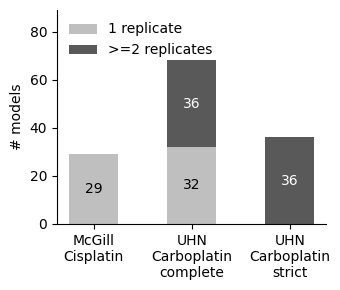

In [10]:
cohort_reps = {
    "McGill\nCisplatin": mcgill_reps,
    "UHN\nCarboplatin\ncomplete": uhn_reps,
    "UHN\nCarboplatin\nstrict": uhn_strict_reps,
}

single = [int((r == 1).sum()) for r in cohort_reps.values()]
multi = [int((r >= 2).sum()) for r in cohort_reps.values()]

x = np.arange(len(cohort_reps))
fig, ax = plt.subplots(figsize=(3.5, 3))
ax.bar(x, single, label="1 replicate", color="0.75", width=0.5)
ax.bar(x, multi, bottom=single, label=">=2 replicates", color="0.35", width=0.5)

for i, (s, m) in enumerate(zip(single, multi)):
    if s:
        ax.text(i, s / 2, str(s), ha="center", va="center", fontsize=10, color="black")
    if m:
        ax.text(i, s + m / 2, str(m), ha="center", va="center", fontsize=10, color="white")

ax.set_xticks(x)
ax.set_xticklabels(cohort_reps.keys())
ax.set_ylabel("# models")
ax.set_ylim(0,89)
ax.legend(frameon=False, loc="upper left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()

out_path = figures_dir / "case3_replicate_single_vs_multi.png"
plt.savefig(out_path, dpi=300)
print("Saved:", out_path)
plt.show()

In [ ]:
replicate_design = pd.DataFrame({
    "cohort": [c.replace("\n", " ") for c in cohort_reps.keys()],
    "n_single_replicate": single,
    "n_multi_replicate": multi,
    "n_total": [s + m for s, m in zip(single, multi)],
})
replicate_design_out = paths["results"] / "case3_replicate_design.csv"
replicate_design.to_csv(replicate_design_out, index=False)
print(f"Saved: {replicate_design_out}")
replicate_design

### PCA of NeST-VNN input features: Mutation / CNA / CND (McGill vs UHN)

Saved: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/3_carboplatin/case3_pca_panel.png


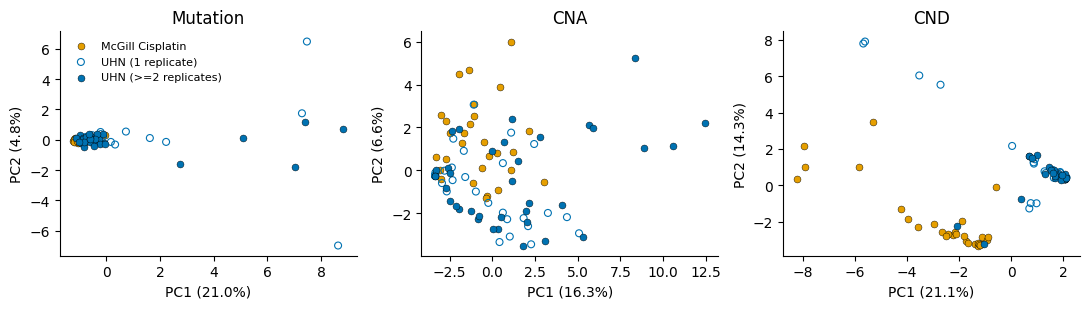

In [11]:
from sklearn.decomposition import PCA

FEATURE_FILES = {
    "Mutation": "cell2mutation.txt",
    "CNA": "cell2amplification.txt",
    "CND": "cell2cndeletion.txt",
}


def load_nest_matrix(nest_dir, fname):
    return pd.read_csv(nest_dir / fname, header=None).to_numpy()


is_strict = (uhn_models["n_replicates"] >= 2).to_numpy()

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))

for ax, ft in zip(axes, ["Mutation", "CNA", "CND"]):
    mcgill_mat = load_nest_matrix(mcgill_dir, FEATURE_FILES[ft])
    uhn_mat = load_nest_matrix(uhn_complete_dir, FEATURE_FILES[ft])

    combined = np.vstack([mcgill_mat, uhn_mat])
    pca = PCA(n_components=2)
    coords = pca.fit_transform(combined)

    mcgill_xy = coords[: len(mcgill_mat)]
    uhn_xy = coords[len(mcgill_mat) :]

    ax.scatter(mcgill_xy[:, 0], mcgill_xy[:, 1], color=COHORT_COLORS["McGill Cisplatin"],
               edgecolor="black", linewidth=0.3, s=25, label="McGill Cisplatin")
    ax.scatter(uhn_xy[~is_strict, 0], uhn_xy[~is_strict, 1], facecolors="none",
               edgecolors=COHORT_COLORS["UHN Carboplatin"], linewidth=0.8, s=25,
               label="UHN (1 replicate)")
    ax.scatter(uhn_xy[is_strict, 0], uhn_xy[is_strict, 1], color=COHORT_COLORS["UHN Carboplatin"],
               edgecolor="black", linewidth=0.3, s=25, label="UHN (>=2 replicates)")

    ax.set_title(ft)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].legend(frameon=False, fontsize=8, loc="best")
plt.tight_layout()

out_path = figures_dir / "case3_pca_panel.png"
plt.savefig(out_path, dpi=300)
print("Saved:", out_path)
plt.show()

### Window-choice justification: is a 10-30 day response window reasonable?

Rather than picking the response window by whichever choice maximizes downstream AUROC (circular), we
check the same two things case 1's MAX_DAY justification did: (i) whether the *uncensored*
treatment-arm slope is confounded with how long a model happened to be followed, and (ii) how the
*median* treatment-arm slope drifts as the candidate window widens -- holding `min.time = 10` fixed and
sweeping `max.time` in weekly steps from 14 to 56 days (see `window_confound_sweep.R`).

In [12]:
def batch_followup_duration(dataset_dir, models_df):
    """Per-batch, treatment-arm follow-up duration, uncensored by any response window
    (max over replicate mice within a batch, matching Xeva's batch-level aggregation unit)."""
    exp = pd.read_csv(paths["datasets"] / dataset_dir / "experiment.csv").set_index("model.id")
    design = pd.read_csv(paths["datasets"] / dataset_dir / "expDesign.csv")
    treatment = design[design["batch.name"].isin(models_df["batch.name"]) & (design["arm"] == "treatment")]

    rows = []
    for batch_name, grp in treatment.groupby("batch.name"):
        days = [exp.loc[[m], "time"].max() for m in grp["model.id"] if m in exp.index]
        if days:
            rows.append({"batch.name": batch_name, "last_observed_day": max(days)})
    return pd.DataFrame(rows)


mcgill_followup = batch_followup_duration("mcgill_breast", mcgill_models)
uhn_followup = batch_followup_duration("uhn_breast", uhn_models)
print(f"McGill: n={len(mcgill_followup)}, median follow-up={mcgill_followup['last_observed_day'].median():.0f} days, "
      f"max={mcgill_followup['last_observed_day'].max():.0f}")
print(f"UHN: n={len(uhn_followup)}, median follow-up={uhn_followup['last_observed_day'].median():.0f} days, "
      f"max={uhn_followup['last_observed_day'].max():.0f}")

McGill: n=29, median follow-up=40 days, max=150
UHN: n=68, median follow-up=53 days, max=286


McGill Cisplatin: 66% of batches followed beyond day 28
McGill Cisplatin: uncensored slope.treatment vs. follow-up day: rho=-0.542, p=2.41e-03, n=29
UHN Carboplatin: 84% of batches followed beyond day 28
UHN Carboplatin: uncensored slope.treatment vs. follow-up day: rho=-0.846, p=1.19e-19, n=68


Saved: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/3_carboplatin/case3_window_confound_diagnostic.png


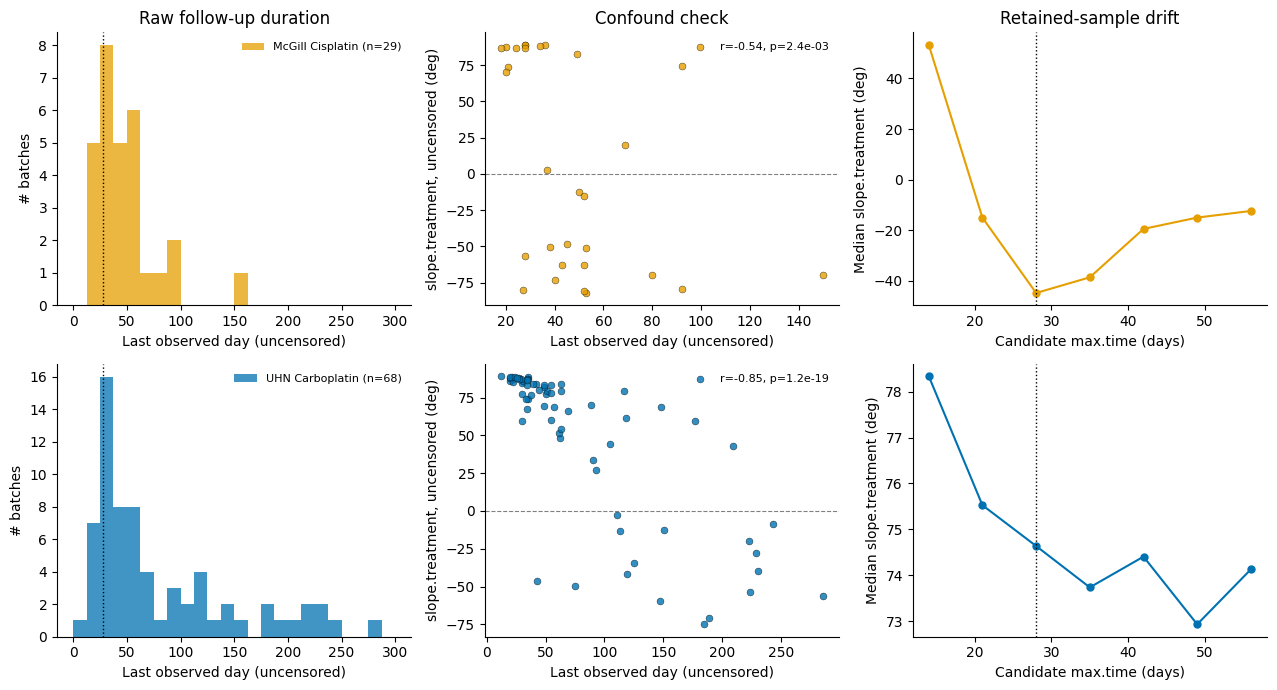

In [13]:
from scipy.stats import spearmanr

CHOSEN_MAX_TIME = 28

FOLLOWUP = {"McGill Cisplatin": mcgill_followup, "UHN Carboplatin": uhn_followup}
FULL = {
    "McGill Cisplatin": pd.read_csv(paths["proc"] / "McGill_slope_full_duration.csv"),
    "UHN Carboplatin": pd.read_csv(paths["proc"] / "UHN_slope_full_duration.csv"),
}
SWEEP = {
    "McGill Cisplatin": pd.read_csv(paths["proc"] / "McGill_slope_sweep.csv"),
    "UHN Carboplatin": pd.read_csv(paths["proc"] / "UHN_slope_sweep.csv"),
}

fig, axes = plt.subplots(2, 3, figsize=(13, 7))

for row, cohort in enumerate(["McGill Cisplatin", "UHN Carboplatin"]):
    color = COHORT_COLORS[cohort]

    # Panel 1: raw follow-up duration
    ax = axes[row, 0]
    fu = FOLLOWUP[cohort]
    bins = np.linspace(0, 300, 25)
    ax.hist(fu["last_observed_day"], bins=bins, alpha=0.75, color=color, label=f"{cohort} (n={len(fu)})")
    pct_past = (fu["last_observed_day"] > CHOSEN_MAX_TIME).mean() * 100
    print(f"{cohort}: {pct_past:.0f}% of batches followed beyond day {CHOSEN_MAX_TIME}")
    ax.axvline(CHOSEN_MAX_TIME, color="black", linestyle=":", linewidth=1)
    ax.set_xlabel("Last observed day (uncensored)")
    ax.set_ylabel("# batches")
    if row == 0:
        ax.set_title("Raw follow-up duration")
    ax.legend(frameon=False, fontsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Panel 2: confound check -- uncensored slope.treatment vs. follow-up day
    ax = axes[row, 1]
    m = FOLLOWUP[cohort].merge(FULL[cohort], on="batch.name").dropna(subset=["last_observed_day", "slope.treatment"])
    rho, p = spearmanr(m["last_observed_day"], m["slope.treatment"])
    ax.scatter(m["last_observed_day"], m["slope.treatment"], color=color,
               edgecolor="black", linewidth=0.3, s=25, alpha=0.8, label=f"r={rho:.2f}, p={p:.1e}")
    print(f"{cohort}: uncensored slope.treatment vs. follow-up day: rho={rho:.3f}, p={p:.2e}, n={len(m)}")
    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    ax.set_xlabel("Last observed day (uncensored)")
    ax.set_ylabel("slope.treatment, uncensored (deg)")
    if row == 0:
        ax.set_title("Confound check")
    ax.legend(frameon=False, fontsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Panel 3: retained-sample median drift across the weekly max.time sweep
    ax = axes[row, 2]
    drift = SWEEP[cohort].groupby("max_time")["slope.treatment"].median()
    ax.plot(drift.index, drift.values, color=color, marker="o", markersize=5)
    ax.axvline(CHOSEN_MAX_TIME, color="black", linestyle=":", linewidth=1)
    ax.set_xlabel("Candidate max.time (days)")
    ax.set_ylabel("Median slope.treatment (deg)")
    if row == 0:
        ax.set_title("Retained-sample drift")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
out_path = figures_dir / "case3_window_confound_diagnostic.png"
plt.savefig(out_path, dpi=300)
print("Saved:", out_path)
plt.show()

### Apply the chosen response window (min.time=10, max.time=28)

Based on the window-choice diagnostic above, recompute both cohorts' slope/angle/mRECIST
with `recompute_sensitivity_min10_max28.R` and apply them to `mcgill_models`/`uhn_models` --
replacing the as-extracted values from `0_xevaset_extraction/` (McGill's happened to
already reflect min.time=10/max.time=30; UHN's reflected the full, highly variable
observed treatment duration instead) -- and overwrite `McGill_cisplatin_models.tsv` /
`UHN_carboplatin_models.tsv` so this is the single place the window choice is applied;
everything downstream in this notebook and in `5-result_intepratation.ipynb` uses these
updated values.

In [14]:
import subprocess

subprocess.run(["Rscript", "recompute_sensitivity_min10_max28.R"], check=True)

MRECIST_WORST_FIRST = ["PD", "SD", "PR", "CR"]


def majority_vote_mrecist(values):
    """Batch-level mRECIST via majority vote across a batch's treatment-arm mice,
    ties broken toward the more resistant call -- same rule used in notebooks 1/2."""
    counts = values.dropna().value_counts()
    if counts.empty:
        return None
    top_count = counts.max()
    tied = counts[counts == top_count].index
    return next(r for r in MRECIST_WORST_FIRST if r in tied)


def windowed_batch_mrecist(dataset_dir, model_sensitivity_df, batch_names):
    exp_dsg = pd.read_csv(paths["datasets"] / dataset_dir / "expDesign.csv")
    treatment_arm = exp_dsg[exp_dsg["arm"] == "treatment"]
    merged = treatment_arm.merge(model_sensitivity_df[["model.id", "mRECIST"]], on="model.id", how="left")
    derived = merged.groupby("batch.name")["mRECIST"].apply(majority_vote_mrecist).rename("mRECIST").reset_index()
    return derived[derived["batch.name"].isin(batch_names)].reset_index(drop=True)


def apply_windowed_sensitivity(models_df, cohort_name, dataset_dir, models_out_path):
    batch_sens = pd.read_csv(paths["proc"] / f"{cohort_name}_batch_sensitivity_10_28day.csv")
    model_sens = pd.read_csv(paths["proc"] / f"{cohort_name}_model_sensitivity_10_28day.csv")
    mrecist_new = windowed_batch_mrecist(dataset_dir, model_sens, models_df["batch.name"])

    updated = models_df.drop(columns=["slope.control", "slope.treatment", "angle", "mRECIST"])
    updated = updated.merge(
        batch_sens[["batch.name", "slope.control", "slope.treatment", "angle"]], on="batch.name", how="left"
    )
    updated = updated.merge(mrecist_new, on="batch.name", how="left")
    updated.to_csv(models_out_path, sep="\t", index=False)
    return updated


mcgill_models = apply_windowed_sensitivity(
    mcgill_models, "McGill", "mcgill_breast", paths["proc"] / "McGill_cisplatin_models.tsv"
)
print("Updated McGill_cisplatin_models.tsv with the 10-28 day window; mRECIST:")
print(mcgill_models["mRECIST"].value_counts())

uhn_models = apply_windowed_sensitivity(
    uhn_models, "UHN", "uhn_breast", paths["proc"] / "UHN_carboplatin_models.tsv"
)
print("\nUpdated UHN_carboplatin_models.tsv with the 10-28 day window; mRECIST:")
print(uhn_models["mRECIST"].value_counts())

Warning message:
package ‘Xeva’ was built under R version 4.4.3 


Saved: ../data/procdata/3_carboplatin/McGill_batch_sensitivity_10_28day.csv ( 135 batches )
Saved: ../data/procdata/3_carboplatin/McGill_model_sensitivity_10_28day.csv ( 241 models )


Warning messages:
1: In mRECIST(dl$time, dl$volume, min.time = min.time, return.detail = TRUE) :
  insufficient data after time 10
2: In mRECIST(dl$time, dl$volume, min.time = min.time, return.detail = TRUE) :
  insufficient data after time 10
3: In mRECIST(dl$time, dl$volume, min.time = min.time, return.detail = TRUE) :
  insufficient data after time 10
4: In mRECIST(dl$time, dl$volume, min.time = min.time, return.detail = TRUE) :
  insufficient data after time 10
5: In regularize.values(x, y, ties, missing(ties), na.rm = na.rm) :
  collapsing to unique 'x' values
6: In regularize.values(x, y, ties, missing(ties), na.rm = na.rm) :
  collapsing to unique 'x' values
7: In regularize.values(x, y, ties, missing(ties), na.rm = na.rm) :
  collapsing to unique 'x' values
8: In regularize.values(x, y, ties, missing(ties), na.rm = na.rm) :
  collapsing to unique 'x' values


Saved: ../data/procdata/3_carboplatin/UHN_batch_sensitivity_10_28day.csv ( 2398 batches )
Saved: ../data/procdata/3_carboplatin/UHN_model_sensitivity_10_28day.csv ( 6409 models )
Updated McGill_cisplatin_models.tsv with the 10-28 day window; mRECIST:
mRECIST
PD    9
PR    7
SD    7
CR    6
Name: count, dtype: int64


There were 50 or more warnings (use warnings() to see the first 50)



Updated UHN_carboplatin_models.tsv with the 10-28 day window; mRECIST:
mRECIST
PD    38
SD    26
PR     3
Name: count, dtype: int64


### Sensitivity validation statistic: growth-curve slope (arctan angle, degrees, bounded +/-90)

Saved: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/3_carboplatin/case3_slope_distribution.png


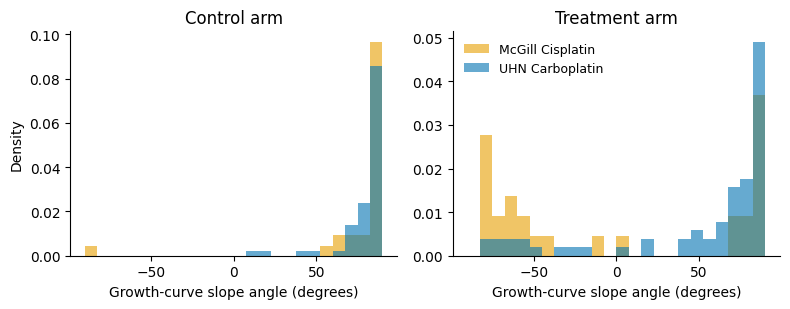

slope.control: KS D=0.322, p=2.24e-02
    McGill: n=29, mean=77.3, median=86.7, std=32.8, range=[-87.0, 89.4]
    UHN: n=67, mean=79.9, median=83.8, std=13.6, range=[14.1, 88.7]
slope.treatment: KS D=0.410, p=1.42e-03
    McGill: n=29, mean=-0.7, median=-44.8, std=74.5, range=[-82.0, 89.0]
    UHN: n=68, mean=50.2, median=74.6, std=52.8, range=[-79.0, 89.2]


In [15]:
from scipy.stats import ks_2samp

fig, axes = plt.subplots(1, 2, figsize=(8, 3.2))
bins = np.linspace(-90, 90, 25)

for ax, col, title in zip(axes, ["slope.control", "slope.treatment"], ["Control arm", "Treatment arm"]):
    ax.hist(mcgill_models[col].dropna(), bins=bins, density=True, alpha=0.6,
            color=COHORT_COLORS["McGill Cisplatin"], label="McGill Cisplatin")
    ax.hist(uhn_models[col].dropna(), bins=bins, density=True, alpha=0.6,
            color=COHORT_COLORS["UHN Carboplatin"], label="UHN Carboplatin")
    ax.set_title(title)
    ax.set_xlabel("Growth-curve slope angle (degrees)")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("Density")
axes[1].legend(frameon=False, fontsize=9)
plt.tight_layout()

out_path = figures_dir / "case3_slope_distribution.png"
plt.savefig(out_path, dpi=300)
print("Saved:", out_path)
plt.show()

for col in ["slope.control", "slope.treatment"]:
    stat, p = ks_2samp(mcgill_models[col].dropna(), uhn_models[col].dropna())
    print(f"{col}: KS D={stat:.3f}, p={p:.2e}")
    for name, df in [("McGill", mcgill_models), ("UHN", uhn_models)]:
        s = df[col].dropna()
        print(f"    {name}: n={len(s)}, mean={s.mean():.1f}, median={s.median():.1f}, "
              f"std={s.std():.1f}, range=[{s.min():.1f}, {s.max():.1f}]")

In [ ]:
# Same K-S test reported in the printout above, recomputed here to save the
# underlying figure statistics as a table (covers both the main-figure treatment-arm
# panel and the supplemental control-arm ECDF panel below, which share this test).
ks_rows = []
for col in ["slope.control", "slope.treatment"]:
    stat, p = ks_2samp(mcgill_models[col].dropna(), uhn_models[col].dropna())
    ks_rows.append({
        "measure": col, "KS_D": stat, "p_value": p,
        "n_McGill": mcgill_models[col].dropna().shape[0],
        "n_UHN": uhn_models[col].dropna().shape[0],
    })
slope_ks_test = pd.DataFrame(ks_rows)
slope_ks_test_out = paths["results"] / "case3_slope_ks_test.csv"
slope_ks_test.to_csv(slope_ks_test_out, index=False)
print(f"Saved: {slope_ks_test_out}")
slope_ks_test

#### Treatment-arm-only panel (main figure), with the growth/regression threshold at 0deg marked

Saved: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/3_carboplatin/case3_slope_treatment_only.png


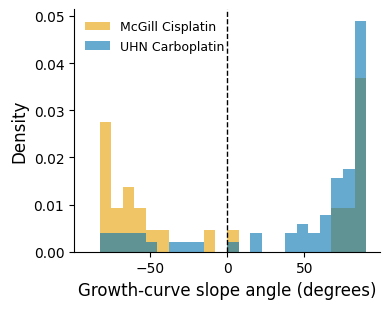

In [16]:
fig, ax = plt.subplots(figsize=(4, 3.2))
bins = np.linspace(-90, 90, 25)

ax.hist(mcgill_models["slope.treatment"].dropna(), bins=bins, density=True, alpha=0.6,
        color=COHORT_COLORS["McGill Cisplatin"], label="McGill Cisplatin")
ax.hist(uhn_models["slope.treatment"].dropna(), bins=bins, density=True, alpha=0.6,
        color=COHORT_COLORS["UHN Carboplatin"], label="UHN Carboplatin")

ax.axvline(0, color="black", linestyle="--", linewidth=1)

ax.set_xlabel("Growth-curve slope angle (degrees)", fontsize=12)
ax.set_ylabel("Density", fontsize = 12)
ax.legend(frameon=False, fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()

out_path = figures_dir / "case3_slope_treatment_only.png"
plt.savefig(out_path, dpi=300)
print("Saved:", out_path)
plt.show()

#### Supplemental panel: control-arm distribution + ECDF with K-S max-gap (Supp Fig 3e)

Same control-arm slope comparison as the left panel above, drawn as distribution + ECDF with the
Kolmogorov-Smirnov max-gap location marked -- the visualization used in the supplementary figure,
which isn't otherwise produced by this notebook.

Saved: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/3_carboplatin/case3_control_arm_ks_test.png
Control-arm slope: KS D=0.322, p=2.24e-02
    McGill: n=29, median=86.7
    UHN: n=67, median=83.8


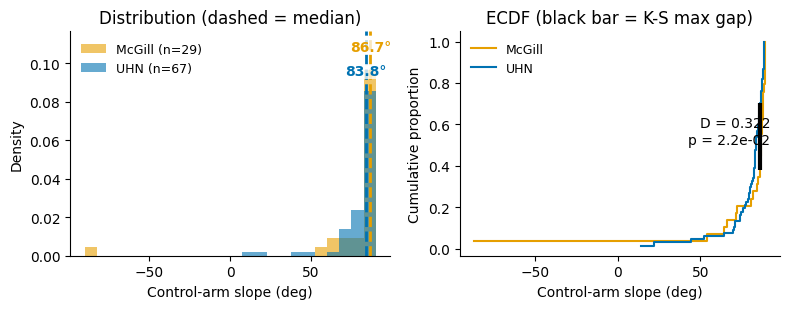

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.2))
bins = np.linspace(-90, 90, 25)

# Panel 1: distribution with median lines annotated
ax = axes[0]
for i, (name, df) in enumerate([("McGill", mcgill_models), ("UHN", uhn_models)]):
    color = COHORT_COLORS[f"{name} Cisplatin" if name == "McGill" else f"{name} Carboplatin"]
    s = df["slope.control"].dropna()
    ax.hist(s, bins=bins, density=True, alpha=0.6, color=color, label=f"{name} (n={len(s)})")
    med = s.median()
    ax.axvline(med, color=color, linestyle="--", linewidth=2)
    ax.text(med, 0.90 - i * 0.11, f"{med:.1f}°", transform=ax.get_xaxis_transform(),
            color=color, fontsize=10, fontweight="bold", ha="center", va="bottom",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=0.5))
ax.set_ylim(top=ax.get_ylim()[1] * 1.15)
ax.set_title("Distribution (dashed = median)")
ax.set_xlabel("Control-arm slope (deg)")
ax.set_ylabel("Density")
ax.legend(frameon=False, fontsize=9, loc="upper left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Panel 2: ECDF with the K-S max-gap location marked
ax = axes[1]
mc = np.sort(mcgill_models["slope.control"].dropna().to_numpy())
uh = np.sort(uhn_models["slope.control"].dropna().to_numpy())
mc_ecdf = np.arange(1, len(mc) + 1) / len(mc)
uh_ecdf = np.arange(1, len(uh) + 1) / len(uh)
ax.step(mc, mc_ecdf, where="post", color=COHORT_COLORS["McGill Cisplatin"], label="McGill")
ax.step(uh, uh_ecdf, where="post", color=COHORT_COLORS["UHN Carboplatin"], label="UHN")

stat, p = ks_2samp(mc, uh)
all_x = np.sort(np.concatenate([mc, uh]))
mc_cdf_at_x = np.searchsorted(mc, all_x, side="right") / len(mc)
uh_cdf_at_x = np.searchsorted(uh, all_x, side="right") / len(uh)
gap = np.abs(mc_cdf_at_x - uh_cdf_at_x)
i_max = int(np.argmax(gap))
x_at_max = all_x[i_max]
y_lo, y_hi = sorted([mc_cdf_at_x[i_max], uh_cdf_at_x[i_max]])
ax.plot([x_at_max, x_at_max], [y_lo, y_hi], color="black", linewidth=3, solid_capstyle="butt")

ax.set_title("ECDF (black bar = K-S max gap)")
ax.set_xlabel("Control-arm slope (deg)")
ax.set_ylabel("Cumulative proportion")
ax.annotate(f"D = {stat:.3f}\np = {p:.1e}", xy=(0.97, 0.5), xycoords="axes fraction", ha="right", fontsize=10)
ax.legend(frameon=False, fontsize=9, loc="upper left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
out_path = figures_dir / "case3_control_arm_ks_test.png"
plt.savefig(out_path, dpi=300)
print("Saved:", out_path)
print(f"Control-arm slope: KS D={stat:.3f}, p={p:.2e}")
for name, df in [("McGill", mcgill_models), ("UHN", uhn_models)]:
    s = df["slope.control"].dropna()
    print(f"    {name}: n={len(s)}, median={s.median():.1f}")
plt.show()